# Treinamento e validação de um  modelo  de  deep  learning utilizando LSTM para capturar padrões temporais nos dados de preços das ações

# IMPORTS

In [9]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import math
import random
import yfinance as yf

# REPRODUTIBILIDADE

In [10]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# DEVICE

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

Usando device: cpu


## COLETA DE DADOS

A Ação definida é a Petrobras com o ticker PETR4.SA.

In [ ]:
# Símbolo da Petrobras na B3 (Yahoo Finance)
symbol = 'PETR4.SA'

# Período histórico que você quer analisar
start_date = '2015-01-01'
end_date = '2025-10-20'

# =====================================
# DOWNLOAD DOS DADOS
# =====================================

print(f"Baixando dados de {symbol} de {start_date} até {end_date}...")

# Baixa os dados do Yahoo Finance
df_petrobras = yf.download(symbol, start=start_date, end=end_date)

# Mostra as primeiras linhas
print(df_petrobras.head(1))
print(df_petrobras.shape)
print(df_petrobras.tail())

Baixando dados de PETR4.SA de 2015-01-01 até 2025-10-21...


C:\Users\DELL\AppData\Local\Temp\ipykernel_8872\1685689717.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_petrobras = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

Price         Close      High       Low      Open    Volume
Ticker     PETR4.SA  PETR4.SA  PETR4.SA  PETR4.SA  PETR4.SA
Date                                                       
2015-01-02  2.57251  2.745659  2.569762  2.745659  49559500
(2689, 5)
Price           Close       High        Low       Open    Volume
Ticker       PETR4.SA   PETR4.SA   PETR4.SA   PETR4.SA  PETR4.SA
Date                                                            
2025-10-14  30.020000  30.459999  29.879999  29.950001  28138200
2025-10-15  29.750000  30.170000  29.670000  30.049999  40261000
2025-10-16  29.450001  29.809999  29.410000  29.740000  28660900
2025-10-17  29.730000  29.950001  29.309999  29.500000  36238600
2025-10-20  29.750000  29.900000  29.480000  29.700001  31442800


# PRÉ-PROCESSAMENTO DE DADOS

Vamos começar apenas utilizando os dados de fechamento do dia para prever séries temporais.

In [13]:
# Cria um DF simples apenas com Close (x) e próximo dia (y)
df_fechamento = pd.DataFrame()
df_fechamento['x'] = df_petrobras['Close']
df_fechamento['y'] = df_petrobras['Close'].shift(-1)

# Remove a última linha com NaN
df_fechamento = df_fechamento[:-1]

# Remove o index
df_fechamento.reset_index(drop=True, inplace=True)

# Visualiza
print("ORIGINAL")
print(df_petrobras.head())
print(df_petrobras.shape)
print()
print("FECHAMENTO")
print(df_fechamento.head())
print(df_fechamento.tail())
print(df_fechamento.shape)


ORIGINAL
Price          Close      High       Low      Open    Volume
Ticker      PETR4.SA  PETR4.SA  PETR4.SA  PETR4.SA  PETR4.SA
Date                                                        
2015-01-02  2.572509  2.745658  2.569761  2.745658  49559500
2015-01-05  2.352637  2.525786  2.344391  2.512044  78385100
2015-01-06  2.275681  2.426844  2.209720  2.393863  84723300
2015-01-07  2.382869  2.399360  2.297668  2.352637  85531000
2015-01-08  2.536780  2.580755  2.402108  2.415850  83306300
(2688, 5)

FECHAMENTO
          x         y
0  2.572509  2.352637
1  2.352637  2.275681
2  2.275681  2.382869
3  2.382869  2.536780
4  2.536780  2.613736
              x          y
2682  29.940001  30.230000
2683  30.230000  30.020000
2684  30.020000  29.750000
2685  29.750000  29.450001
2686  29.450001  29.730000
(2687, 2)


# RESHAPE DOS VALORES DE ENTRADA

In [14]:
values = df_fechamento['x'].values.reshape(-1, 1)
values

array([[ 2.57250881],
       [ 2.35263658],
       [ 2.27568126],
       ...,
       [30.02000046],
       [29.75      ],
       [29.45000076]])

# Escala para [0,1] (importante para LSTM)

In [15]:
scaler = MinMaxScaler(feature_range=(0, 1))
values_scaled = scaler.fit_transform(values)
values_scaled

array([[0.04109654],
       [0.03472499],
       [0.03249495],
       ...,
       [0.83648129],
       [0.82865711],
       [0.81996361]])

# SEQUENCIA DE DIAS: quantos dias anteriores usar para predizer o próximo dia

In [16]:
SEQ_LEN = 10  # você pode ajustar (5, 10, 20...)
def create_sequences(data, seq_len):
    """
    data: array shape (N, 1)
    retorna: X (num_samples, seq_len, 1), y (num_samples,)
    """
    xs = []
    ys = []
    for i in range(len(data) - seq_len):
        x = data[i:i+seq_len]
        y = data[i+seq_len]  # próximo valor após a janela
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(values_scaled, SEQ_LEN)
print(X.shape)
print(y.shape)

(2677, 10, 1)
(2677, 1)


# SEPARA DADOS EM treino, teste e validação

In [17]:
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

n = len(X)
n_train = int(n * train_ratio)
n_val = int(n * val_ratio)

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]

print("Divisões:", X_train.shape, X_val.shape, X_test.shape)


Divisões: (1873, 10, 1) (401, 10, 1) (403, 10, 1)


# Dataset e Dataloader - PYTORCH

In [18]:
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        # X shape (N, seq_len, 1)
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # retorna (seq, target)
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32
train_ds = TimeSeriesDataset(X_train, y_train)
val_ds = TimeSeriesDataset(X_val, y_val)
test_ds = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# MODELO LSTM

In [19]:
class LSTMForecast(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=50, num_layers=2, output_dim=1, dropout=0.2):
        super(LSTMForecast, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        # camada fully-connected para mapear hidden -> saída
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        batch_size = x.size(0)
        # inicializar hidden e cell states com zeros
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(x.device)

        out, _ = self.lstm(x, (h0, c0))  # out: (batch, seq_len, hidden_dim)
        # Pegar apenas a última saída do sequence (many-to-one)
        out = out[:, -1, :]  # (batch, hidden_dim)
        out = self.fc(out)   # (batch, output_dim)
        return out

# Instanciar modelo
model = LSTMForecast(input_dim=1, hidden_dim=64, num_layers=2, output_dim=1, dropout=0.2).to(device)
print(model)

LSTMForecast(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


# Critério e otimizador

In [20]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# O ReduceLROnPlateau ajusta automaticamente a taxa de aprendizado (learning rate) quando o modelo entra em um platô
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5)


# TREINAR MODELO

In [21]:
EPOCHS = 100  # ajuste conforme precisar
best_val_loss = float('inf')
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS+1):
    model.train()
    train_losses = []
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)  # (batch, seq_len, 1)
        y_batch = y_batch.to(device)  # (batch, 1)

        optimizer.zero_grad()
        y_pred = model(X_batch).squeeze()  # (batch,)
        loss = criterion(y_pred, y_batch.squeeze())
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # validação
    model.eval()
    val_losses = []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch.squeeze())
            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses) if len(val_losses) > 0 else None
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # scheduler step
    if val_loss is not None:
        scheduler.step(val_loss)

    # salvar melhor modelo
    if val_loss is not None and val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_lstm_model.pth")

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{EPOCHS}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}")

print("Treino finalizado. Melhor val_loss:", best_val_loss)

Epoch 1/100  train_loss=0.011505  val_loss=0.195828
Epoch 10/100  train_loss=0.000170  val_loss=0.003146
Epoch 20/100  train_loss=0.000143  val_loss=0.002015
Epoch 30/100  train_loss=0.000130  val_loss=0.002220
Epoch 40/100  train_loss=0.000126  val_loss=0.001968
Epoch 50/100  train_loss=0.000124  val_loss=0.001999
Epoch 60/100  train_loss=0.000135  val_loss=0.002006
Epoch 70/100  train_loss=0.000128  val_loss=0.001995
Epoch 80/100  train_loss=0.000127  val_loss=0.001997
Epoch 90/100  train_loss=0.000124  val_loss=0.001992
Epoch 100/100  train_loss=0.000127  val_loss=0.001990
Treino finalizado. Melhor val_loss: 0.001491122382084051


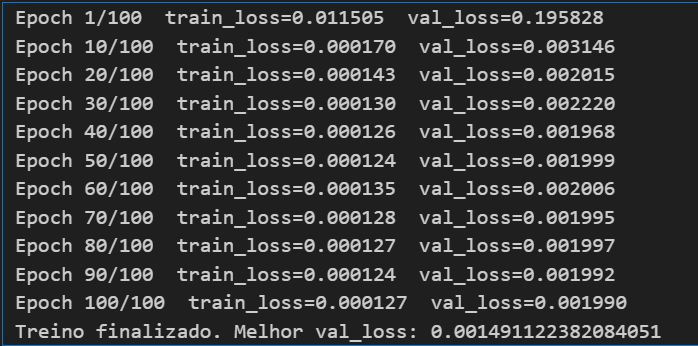

Durante o treinamento, o modelo LSTM apresentou uma rápida redução das perdas de treino e validação nas primeiras épocas, convergindo de forma estável após cerca de 20 iterações.
A menor perda de validação obtida foi de 0.00149, demonstrando boa capacidade de generalização.
Observou-se também que as perdas de treino e validação se mantiveram próximas, o que indica ausência de overfitting.

# AVALIAÇÃO DO MODELO

In [22]:
# Carrega melhor modelo
model.load_state_dict(torch.load("best_lstm_model.pth"))
model.eval()

preds = []
targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        y_pred = model(X_batch).squeeze().cpu().numpy()
        preds.append(y_pred)
        targets.append(y_batch.squeeze().cpu().numpy())

preds = np.concatenate(preds, axis=0)
targets = np.concatenate(targets, axis=0)

# Inverte escala (MinMaxScaler)
preds_inv = scaler.inverse_transform(preds.reshape(-1,1)).reshape(-1)
targets_inv = scaler.inverse_transform(targets.reshape(-1,1)).reshape(-1)

rmse = math.sqrt(mean_squared_error(targets_inv, preds_inv))
print(f"Test RMSE = {rmse:.6f}")

Test RMSE = 1.202218


In [23]:
df_fechamento.tail()

,x,y
2682,29.940001,30.230000
2683,30.230000,30.020000
2684,30.020000,29.750000
2685,29.750000,29.450001
2686,29.450001,29.730000


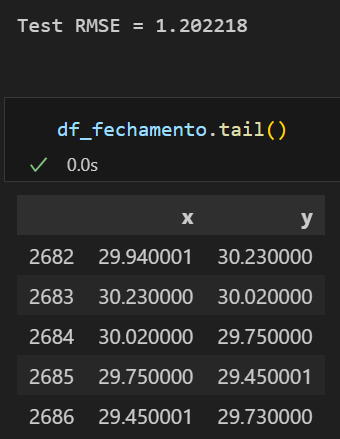

In [26]:
1.2/30

0.04

Os valores da Petrobras ficam em torno de 30 reais portanto o desvio de 1,20 é considerado bom, ficando em torno de 1.2/30 = 4%.

# PLOT REAL X PREVISTO

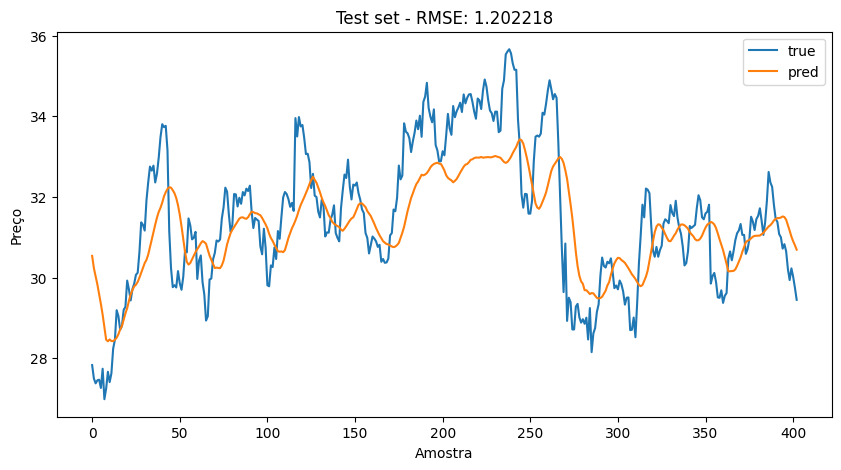

In [27]:
plt.figure(figsize=(10,5))
plt.plot(targets_inv, label="true")
plt.plot(preds_inv, label="pred")
plt.legend()
plt.title(f"Test set - RMSE: {rmse:.6f}")
plt.xlabel("Amostra")
plt.ylabel("Preço")
plt.show()

# PREVISÃO DO ULTIMO DIA (AINDA NAO EXISTE NO DF)

In [28]:
def predict_next(model, last_seq, scaler):
    """
    last_seq: array shape (seq_len, 1) com os valores originais (não escalados) OU escalados.
    Se não estiver escalado, escalamos aqui.
    Retorna valor previso na escala original.
    """
    model.eval()
    arr = np.array(last_seq).reshape(-1,1)
    # detectar se já está escalado (valor entre 0 e 1)
    if arr.max() > 1.0 or arr.min() < 0.0:
        arr_scaled = scaler.transform(arr)
    else:
        arr_scaled = arr

    input_seq = torch.tensor(arr_scaled.reshape(1, arr_scaled.shape[0], 1), dtype=torch.float32).to(device)
    with torch.no_grad():
        y_pred = model(input_seq).cpu().numpy().reshape(-1,1)
    y_pred_inv = scaler.inverse_transform(y_pred)
    return y_pred_inv.ravel()[0]

last_seq_real = values[-SEQ_LEN:]  # últimos SEQ_LEN valores (não escalados)
next_pred = predict_next(model, last_seq_real, scaler)
print("Próximo dia (predição) =", next_pred)

Próximo dia (predição) = 30.592373
